In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vnstock.api.quote import Quote
print("All libraries loaded")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

All libraries loaded
pandas version: 3.0.3
numpy version: 2.4.4


In [5]:
# Test fetching data for VNM (Vinamilk) for 1 month
q = Quote(symbol='VNM', source='VCI')
df_test = q.history(start='2025-04-01', end='2025-05-01', interval='1D')

print(df_test.head())
print(f"\nNumber of trading days: {len(df_test)}")
print(f"\nColumns: {df_test.columns.tolist()}")

        time   open   high    low  close   volume
0 2025-03-25  56.92  56.92  56.46  56.64  2327043
1 2025-03-26  56.74  57.10  56.46  56.46  1849811
2 2025-03-27  56.46  56.74  56.37  56.37  2233560
3 2025-03-28  56.27  56.37  55.54  55.63  5443940
4 2025-03-31  56.09  56.83  55.91  55.91  5308209

Number of trading days: 25

Columns: ['time', 'open', 'high', 'low', 'close', 'volume']


In [6]:
# List of 8 HOSE blue-chip stocks
tickers = ['VNM', 'VIC', 'VHM', 'FPT', 'HPG', 'MWG', 'VCB', 'MBB']

# Time range: 3 recent years
start_date = '2022-01-01'
end_date = '2025-05-01'

# Dictionary to store closing prices of each stock
all_prices = {}

for ticker in tickers:
    print(f"Fetching data: {ticker}...")
    try:
        q = Quote(symbol=ticker, source='VCI')
        df = q.history(start=start_date, end=end_date, interval='1D')
        df['time'] = pd.to_datetime(df['time'])
        all_prices[ticker] = df.set_index('time')['close']
        print(f"  -> Loaded {len(df)} trading days")
    except Exception as e:
        print(f"  -> Error: {e}")

# Combine all into a single DataFrame
prices_df = pd.DataFrame(all_prices)
print(f"\nSummary: {prices_df.shape[0]} days x {prices_df.shape[1]} stocks")
print("\nFirst 5 rows:")
print(prices_df.head())
print("\nLast 5 rows:")
print(prices_df.tail())

Fetching data: VNM...
  -> Loaded 871 trading days
Fetching data: VIC...
  -> Loaded 871 trading days
Fetching data: VHM...
  -> Loaded 871 trading days
Fetching data: FPT...
  -> Loaded 871 trading days
Fetching data: HPG...
  -> Loaded 871 trading days
Fetching data: MWG...
  -> Loaded 871 trading days
Fetching data: VCB...
  -> Loaded 871 trading days
Fetching data: MBB...
  -> Loaded 871 trading days

Summary: 871 days x 8 stocks

First 5 rows:
              VNM    VIC    VHM    FPT    HPG    MWG    VCB    MBB
time                                                              
2021-11-01  70.51  47.90  81.91  48.63  31.36  62.56  42.23  12.82
2021-11-02  69.88  47.90  82.59  48.78  31.25  62.03  42.62  12.82
2021-11-03  69.10  47.65  80.55  48.78  31.30  61.98  42.97  13.16
2021-11-04  69.26  47.50  80.35  48.73  31.70  62.51  42.84  13.05
2021-11-05  69.88  47.50  79.67  49.54  31.87  63.52  42.44  12.93

Last 5 rows:
              VNM    VIC   VHM    FPT    HPG    MWG    VCB    MB

In [7]:
# Check for missing data in each stock
print("Missing values per stock:")
print(prices_df.isna().sum())

# Drop rows with any missing values
prices_clean = prices_df.dropna()
print(f"\nBefore cleaning: {prices_df.shape[0]} days")
print(f"After cleaning:  {prices_clean.shape[0]} days")
print(f"Dropped: {prices_df.shape[0] - prices_clean.shape[0]} days")

Missing values per stock:
VNM    0
VIC    0
VHM    0
FPT    0
HPG    0
MWG    0
VCB    0
MBB    0
dtype: int64

Before cleaning: 871 days
After cleaning:  871 days
Dropped: 0 days


In [8]:
# Save cleaned data to CSV file in the data folder
output_path = '../data/prices.csv'
prices_clean.to_csv(output_path)

print(f"Data saved to: {output_path}")
print(f"Date range: {prices_clean.index.min().date()} to {prices_clean.index.max().date()}")
print(f"Total trading days: {len(prices_clean)}")
print(f"Number of stocks: {prices_clean.shape[1]}")

Data saved to: ../data/prices.csv
Date range: 2021-11-01 to 2025-04-29
Total trading days: 871
Number of stocks: 8


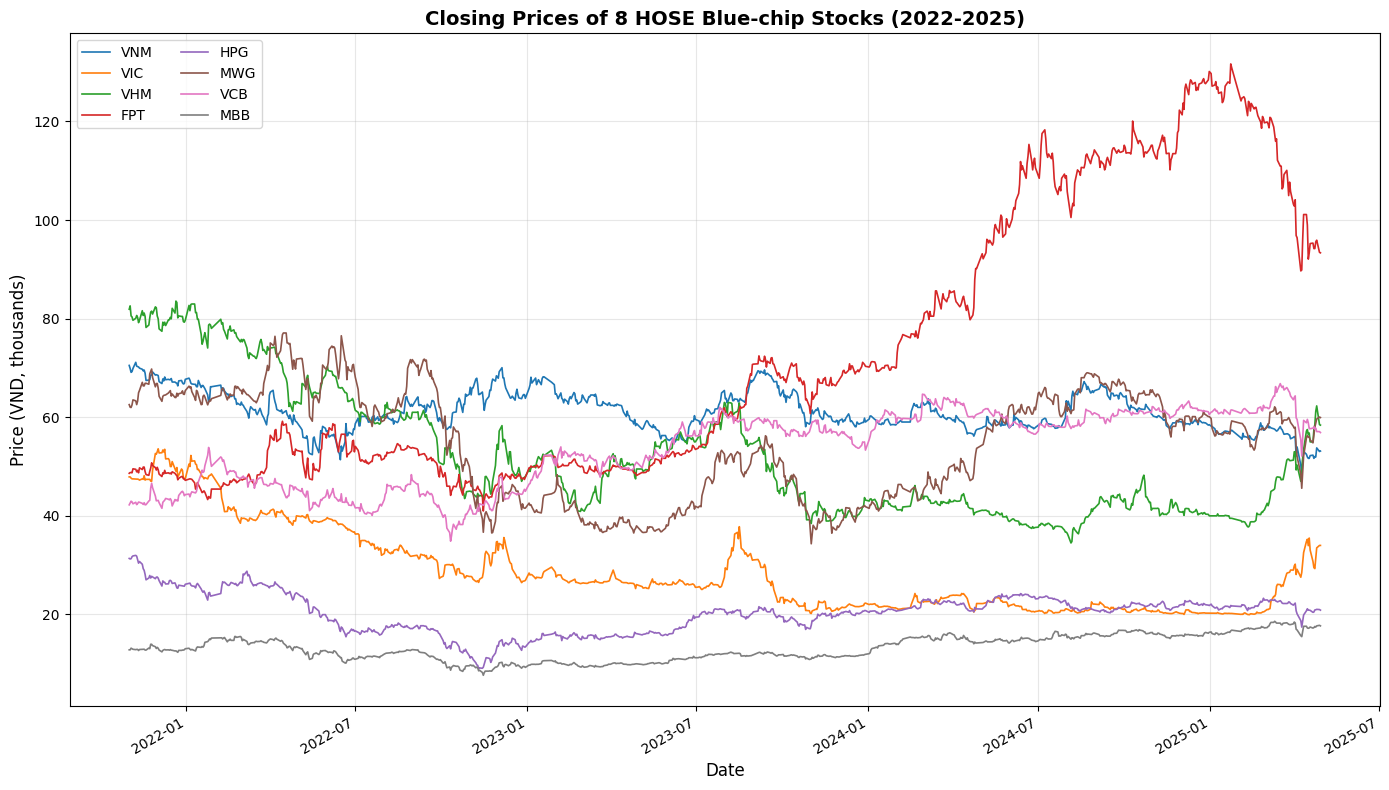

In [9]:
# Plot closing prices of all 8 stocks
fig, ax = plt.subplots(figsize=(14, 8))
prices_clean.plot(ax=ax, linewidth=1.2)

ax.set_title('Closing Prices of 8 HOSE Blue-chip Stocks (2022-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (VND, thousands)', fontsize=12)
ax.legend(loc='upper left', ncol=2, fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()